# NVDA 2026 YTD 日线与期权隐含波动率

读取受管的 Massive NVDA 股票日聚合、OPRA NVDA 期权日聚合和内部 IV Feature Dataset。Notebook 不调用 API。期权 IV 使用日收盘价、调整后 NVDA 收盘价和可配置平坦利率/股息率，通过内部 Black-Scholes 求解；NVDA 期权为美式，因此结果是 European approximation，不是 Massive vendor IV，也不是可执行 bid/ask IV。

In [1]:
from pathlib import Path
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import pyarrow.dataset as ds
import pyarrow.parquet as pq

ROOT = Path.cwd()
if not (ROOT / 'kairos').exists(): ROOT = ROOT.parent
EQUITY_DATASET = os.environ.get('NVDA_EQUITY_DATASET', 'equity.us.massive.nvda.day-aggs.2026-ytd.v1')
OPTION_DATASET = os.environ.get('NVDA_OPTION_DATASET', 'options.us.massive.nvda.day-aggs.2026-ytd.v1')
IV_DATASET = os.environ.get('NVDA_IV_DATASET', 'features.us.massive.nvda.close-iv.2026-ytd.v1')
CURATED = ROOT / 'data/curated/provider=massive'
FEATURES = ROOT / 'data/features/provider=massive'
print({'equity': EQUITY_DATASET, 'options': OPTION_DATASET, 'iv': IV_DATASET})

{'equity': 'equity.us.massive.nvda.day-aggs.2026-ytd.v1', 'options': 'options.us.massive.nvda.day-aggs.2026-ytd.v1', 'iv': 'features.us.massive.nvda.close-iv.2026-ytd.v1'}


## 1. Dataset 血缘与质量

In [2]:
equity_root = CURATED / f'dataset={EQUITY_DATASET}'
option_root = CURATED / f'dataset={OPTION_DATASET}'
iv_root = FEATURES / f'dataset={IV_DATASET}'
for path in (equity_root, option_root, iv_root):
    if not path.exists(): raise FileNotFoundError(path)
equity_manifest = json.loads((equity_root / 'manifest.json').read_text())
option_manifest = json.loads((option_root / 'manifest.json').read_text())
iv_manifest = json.loads((iv_root / 'manifest.json').read_text())
iv_quality = json.loads((iv_root / 'quality.json').read_text())
iv_lineage = json.loads((iv_root / 'lineage.json').read_text())
assert iv_quality['publishable'] and iv_manifest['option_dataset_id'] == OPTION_DATASET
display(pd.DataFrame([{
    'equity_bars': equity_manifest['rows'], 'option_rows': option_manifest['rows'],
    'iv_converged': iv_manifest['converged_rows'], 'iv_coverage': float(iv_quality['iv_coverage']),
    'risk_free_rate': iv_manifest['risk_free_rate'], 'dividend_yield': iv_manifest['dividend_yield'],
    'model': iv_lineage['model'], 'iv_dataset_hash': iv_manifest['dataset_sha256'],
}]))
display(pd.DataFrame(sorted(iv_quality['status_counts'].items()), columns=['solver_status','rows']).sort_values('rows', ascending=False))

,equity_bars,option_rows,iv_converged,iv_coverage,risk_free_rate,dividend_yield,model,iv_dataset_hash
0,133,303007,279782,0.923352,0.04,0.0003,Black-Scholes European approximation for Ameri...,2f6b394b3198ce2797e98915de2453268fd1a0795d5da3...


,solver_status,rows
0,converged,279782
3,price_out_of_bounds,15255
1,expired_at_close,6907
2,not_bracketed,1063


## 2. NVDA 2026 YTD 日 K 线（调整后）

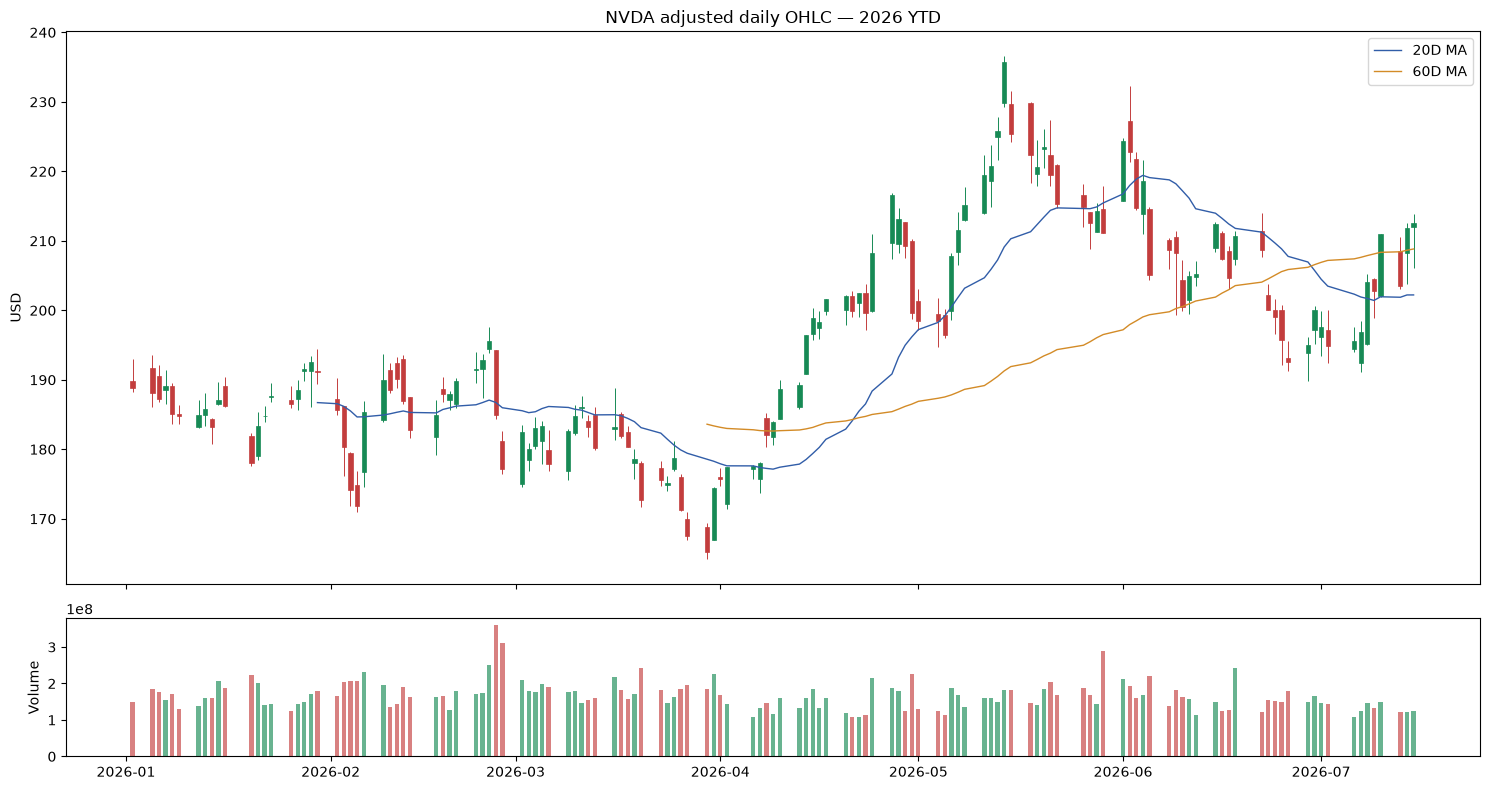

,ticker,instrument_id,event_date,window_start,available_time,open,high,low,close,volume,transactions,vwap
123,NVDA,equity:us:NVDA,2026-07-01,2026-07-01 04:00:00+00:00,2026-07-01 20:00:00+00:00,196.20,199.850,193.45,197.58,1.461476e+08,2330312,197.0727
124,NVDA,equity:us:NVDA,2026-07-02,2026-07-02 04:00:00+00:00,2026-07-02 20:00:00+00:00,197.14,200.055,192.35,194.83,1.423855e+08,2549201,195.0961
125,NVDA,equity:us:NVDA,2026-07-06,2026-07-06 04:00:00+00:00,2026-07-06 20:00:00+00:00,194.42,197.550,193.99,195.55,1.089990e+08,2212755,195.9732
126,NVDA,equity:us:NVDA,2026-07-07,2026-07-07 04:00:00+00:00,2026-07-07 20:00:00+00:00,192.37,198.410,191.14,196.93,1.241546e+08,2384250,195.1014
127,NVDA,equity:us:NVDA,2026-07-08,2026-07-08 04:00:00+00:00,2026-07-08 20:00:00+00:00,195.18,205.160,195.06,204.12,1.474191e+08,2625224,200.9618
128,NVDA,equity:us:NVDA,2026-07-09,2026-07-09 04:00:00+00:00,2026-07-09 20:00:00+00:00,204.46,204.585,198.96,202.78,1.320374e+08,2373992,202.3493
129,NVDA,equity:us:NVDA,2026-07-10,2026-07-10 04:00:00+00:00,2026-07-10 20:00:00+00:00,202.00,211.000,201.92,210.96,1.484210e+08,2577865,208.6258
130,NVDA,equity:us:NVDA,2026-07-13,2026-07-13 04:00:00+00:00,2026-07-13 20:00:00+00:00,208.54,210.570,203.00,203.53,1.214110e+08,2473627,205.6481
131,NVDA,equity:us:NVDA,2026-07-14,2026-07-14 04:00:00+00:00,2026-07-14 20:00:00+00:00,208.20,212.550,203.80,211.80,1.206576e+08,2356930,209.5097
132,NVDA,equity:us:NVDA,2026-07-15,2026-07-15 04:00:00+00:00,2026-07-15 20:00:00+00:00,211.96,213.810,206.04,212.50,1.247972e+08,2421483,210.4754


In [3]:
stock = pq.read_table(equity_root / equity_manifest['file']).to_pandas().sort_values('event_date')
stock['event_date'] = pd.to_datetime(stock['event_date'])
for column in ('open','high','low','close','volume','vwap'): stock[column] = stock[column].map(lambda value: float(value) if value is not None else np.nan)
fig, (ax, volume_ax) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={'height_ratios':[4,1]})
dates = mdates.date2num(stock.event_date.dt.to_pydatetime())
for x, row in zip(dates, stock.itertuples()):
    color = '#178a55' if row.close >= row.open else '#c33d3d'
    ax.vlines(x, row.low, row.high, color=color, linewidth=.7)
    body_low, body_height = min(row.open,row.close), max(abs(row.close-row.open), .03)
    ax.add_patch(Rectangle((x-.32, body_low), .64, body_height, facecolor=color, edgecolor=color, linewidth=.5))
    volume_ax.bar(x, row.volume, width=.65, color=color, alpha=.65)
ax.plot(dates, stock.close.rolling(20).mean(), label='20D MA', color='#315da8', linewidth=1)
ax.plot(dates, stock.close.rolling(60).mean(), label='60D MA', color='#d38b27', linewidth=1)
ax.set_title('NVDA adjusted daily OHLC — 2026 YTD'); ax.set_ylabel('USD'); ax.legend()
volume_ax.set_ylabel('Volume'); volume_ax.xaxis_date(); volume_ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout(); plt.show()
display(stock.tail(10))

## 3. NVDA 全量期权日收盘 IV

In [4]:
iv_files = [iv_root / item['path'] for item in iv_manifest['files']]
iv = ds.dataset(iv_files, format='parquet').to_table().to_pandas()
iv['event_date'] = pd.to_datetime(iv['event_date']); iv['expiry'] = pd.to_datetime(iv['expiry'])
for column in ('strike','close','volume'): iv[column] = iv[column].map(float)
valid = iv[(iv.solver_status == 'converged') & iv.implied_volatility.notna()].copy()
print({'all_option_rows': len(iv), 'valid_iv_rows': len(valid), 'first': iv.event_date.min(), 'last': iv.event_date.max()})
display(valid[['event_date','ticker','expiry','right','strike','close','underlying_close','moneyness','implied_volatility','volume']].head())

{'all_option_rows': 303007, 'valid_iv_rows': 279782, 'first': Timestamp('2026-01-02 00:00:00'), 'last': Timestamp('2026-07-14 00:00:00')}


,event_date,ticker,expiry,right,strike,close,underlying_close,moneyness,implied_volatility,volume
92,2026-01-02,O:NVDA260109C00060000,2026-01-09,call,60.0,128.90,188.85,0.317712,2.529277,9.0
93,2026-01-02,O:NVDA260109C00065000,2026-01-09,call,65.0,123.99,188.85,0.344189,3.077383,5.0
94,2026-01-02,O:NVDA260109C00070000,2026-01-09,call,70.0,119.10,188.85,0.370665,3.161306,27.0
95,2026-01-02,O:NVDA260109C00075000,2026-01-09,call,75.0,114.01,188.85,0.397141,2.725712,4.0
96,2026-01-02,O:NVDA260109C00080000,2026-01-09,call,80.0,108.99,188.85,0.423617,2.470608,1.0


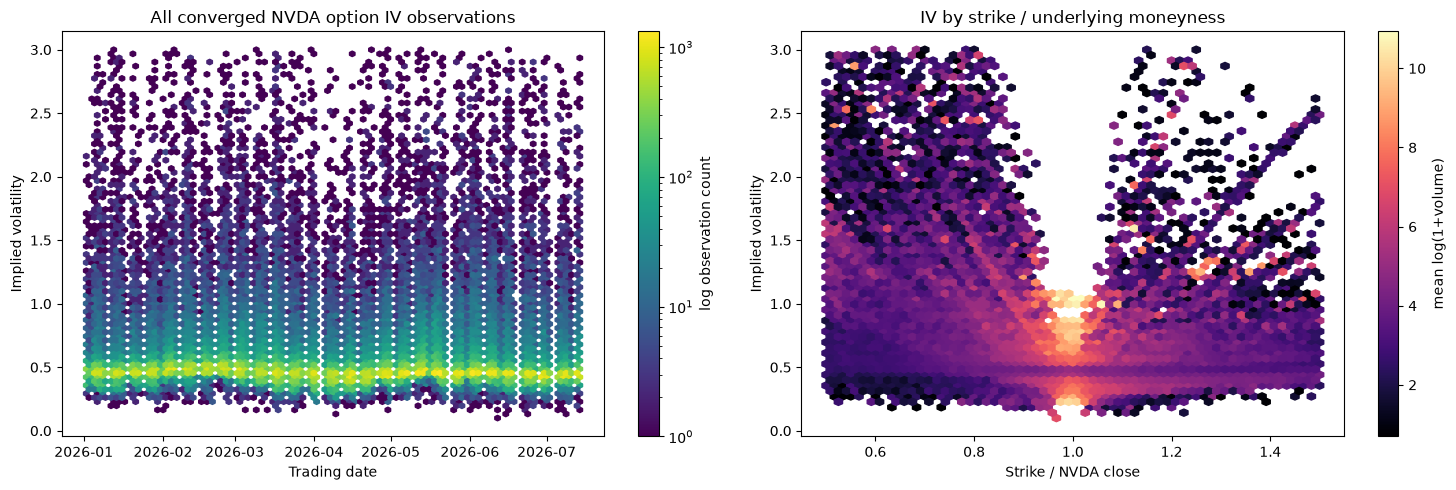

In [5]:
view = valid[(valid.implied_volatility > 0) & (valid.implied_volatility <= 3) & valid.moneyness.between(.5,1.5)]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
date_numbers = mdates.date2num(view.event_date.dt.to_pydatetime())
h1 = axes[0].hexbin(date_numbers, view.implied_volatility, gridsize=(90,45), bins='log', mincnt=1, cmap='viridis')
axes[0].xaxis_date(); axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].set_title('All converged NVDA option IV observations'); axes[0].set_ylabel('Implied volatility'); axes[0].set_xlabel('Trading date')
fig.colorbar(h1, ax=axes[0], label='log observation count')
h2 = axes[1].hexbin(view.moneyness, view.implied_volatility, C=np.log1p(view.volume), reduce_C_function=np.mean, gridsize=60, mincnt=1, cmap='magma')
axes[1].set_title('IV by strike / underlying moneyness'); axes[1].set_xlabel('Strike / NVDA close'); axes[1].set_ylabel('Implied volatility')
fig.colorbar(h2, ax=axes[1], label='mean log(1+volume)')
plt.tight_layout(); plt.show()

## 4. 近 ATM 30–60 DTE IV 时间序列

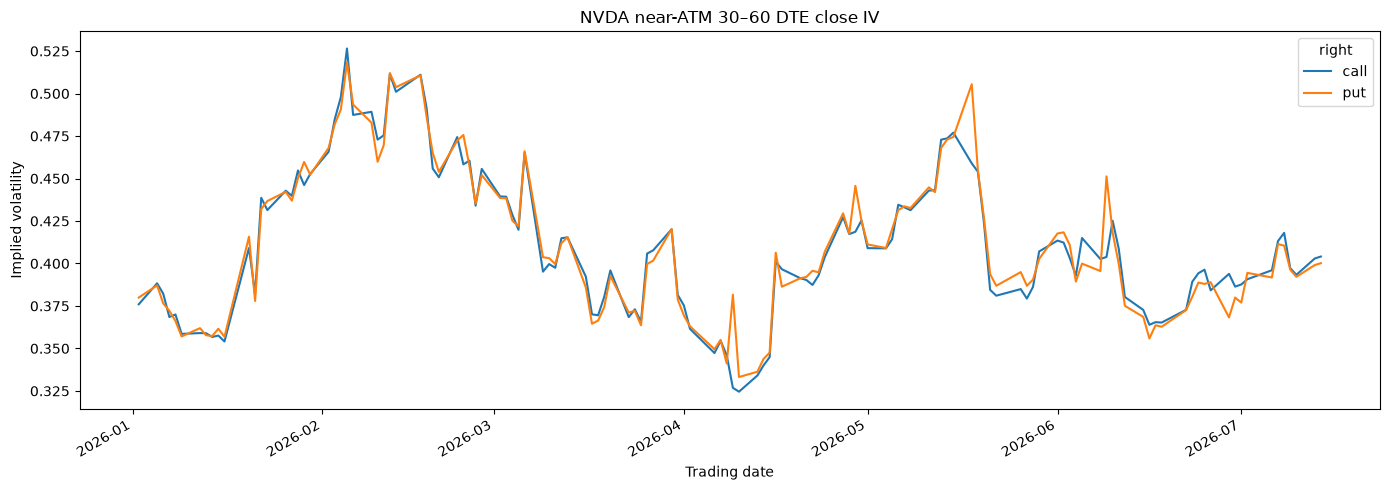

,event_date,right,ticker,expiry,strike,moneyness,implied_volatility,volume
244,2026-06-30,call,O:NVDA260821C00200000,2026-08-21,200.0,0.999550,0.386381,5613.0
245,2026-06-30,put,O:NVDA260821P00200000,2026-08-21,200.0,0.999550,0.379936,1774.0
246,2026-07-01,call,O:NVDA260821C00200000,2026-08-21,200.0,1.012248,0.387647,7355.0
247,2026-07-01,put,O:NVDA260821P00200000,2026-08-21,200.0,1.012248,0.376970,2001.0
248,2026-07-02,call,O:NVDA260821C00195000,2026-08-21,195.0,1.000873,0.390739,2812.0
249,2026-07-02,put,O:NVDA260821P00195000,2026-08-21,195.0,1.000873,0.394475,1434.0
250,2026-07-06,call,O:NVDA260821C00195000,2026-08-21,195.0,0.997187,0.396020,2632.0
251,2026-07-06,put,O:NVDA260821P00195000,2026-08-21,195.0,0.997187,0.391741,1734.0
252,2026-07-07,call,O:NVDA260821C00195000,2026-08-21,195.0,0.990200,0.413213,3690.0
253,2026-07-07,put,O:NVDA260821P00195000,2026-08-21,195.0,0.990200,0.411422,3598.0


In [6]:
near = valid[valid.dte_calendar.between(30,60) & valid.moneyness.between(.95,1.05) & (valid.volume > 0)].copy()
near['distance'] = (near.moneyness - 1).abs()
representative = near.sort_values(['event_date','right','distance','volume'], ascending=[True,True,True,False]).groupby(['event_date','right'], as_index=False).first()
pivot = representative.pivot(index='event_date', columns='right', values='implied_volatility')
ax = pivot.plot(figsize=(14,5), title='NVDA near-ATM 30–60 DTE close IV')
ax.set_ylabel('Implied volatility'); ax.set_xlabel('Trading date'); plt.tight_layout(); plt.show()
display(representative[['event_date','right','ticker','expiry','strike','moneyness','implied_volatility','volume']].tail(20))

## 5. 最新共同交易日的波动率微笑

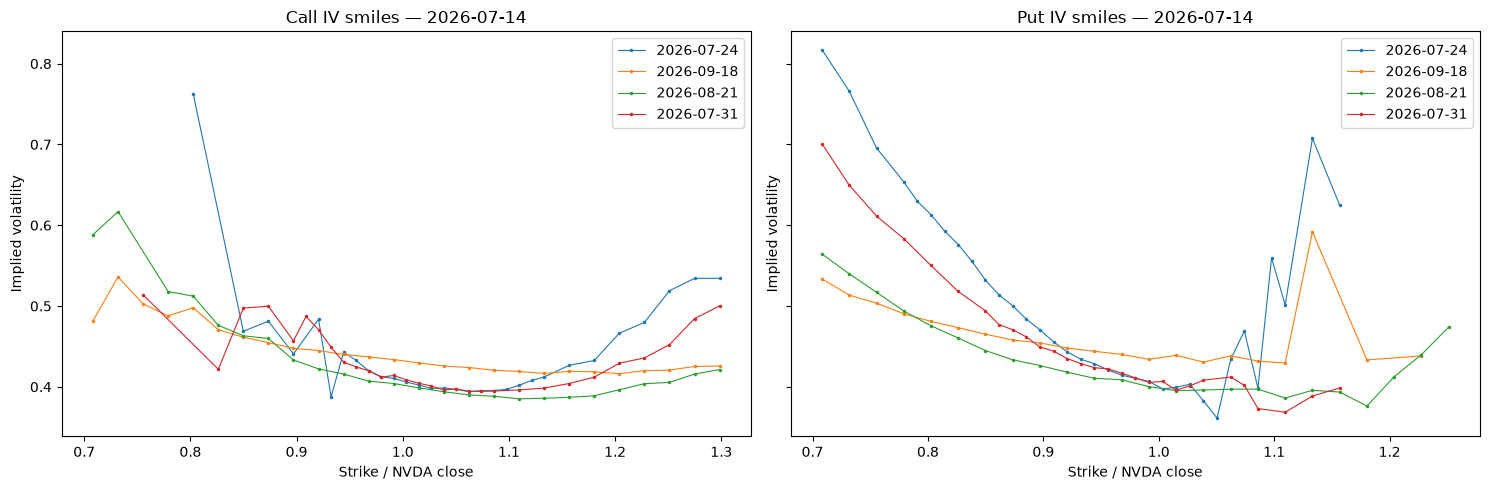

In [7]:
latest = valid.event_date.max()
latest_rows = valid[(valid.event_date == latest) & valid.dte_calendar.between(7,90) & valid.moneyness.between(.7,1.3)]
expiries = (latest_rows.groupby('expiry').volume.sum().sort_values(ascending=False).head(4).index)
fig, axes = plt.subplots(1, 2, figsize=(15,5), sharey=True)
for expiry in expiries:
    for right, ax in (('call',axes[0]),('put',axes[1])):
        smile = latest_rows[(latest_rows.expiry == expiry) & (latest_rows.right == right)].sort_values('moneyness')
        ax.plot(smile.moneyness, smile.implied_volatility, marker='.', markersize=3, linewidth=.8, label=str(expiry.date()))
axes[0].set_title(f'Call IV smiles — {latest.date()}'); axes[1].set_title(f'Put IV smiles — {latest.date()}')
for ax in axes: ax.set_xlabel('Strike / NVDA close'); ax.set_ylabel('Implied volatility'); ax.legend()
plt.tight_layout(); plt.show()

## 使用边界

- 股票日线为 `adjusted=true` 的 Massive aggregate；期权来自 OPRA Day Aggregates。
- 期权 close 是成交聚合收盘，不是同步 bid/ask mid；零成交和异常套利价格不会强求 IV。
- 使用固定年化无风险利率 4% 和股息率 0.03%，均记录在 lineage；正式估值应接入 point-in-time rate/dividend curves。
- Black-Scholes 对美式 NVDA 期权是研究近似；深度实值、临近分红和临近到期处误差可能较大。
- 期权数据截至 2026-07-14，股票日线截至 2026-07-15；IV 只使用共同日期。